# Dynex SDK - Simple Grover Native Gate Circuit Example

First we import the required packages:

In [1]:
from pennylane import numpy as np
import pennylane as qml
import math
from dynex import DynexConfig, ComputeBackend, DynexCircuit

config = DynexConfig(compute_backend=ComputeBackend.QPU, qpu_model="apollo_rc1", use_notebook_output=True)

We define our circuit "Grover Search for Integer Factorization":

In [2]:
n = 6
nimWiresPQ = max(2, math.ceil(math.log2(n + 1) / 2))
numWiresSOL = math.ceil(math.log2(n))
wires_p = list(range(nimWiresPQ))
wires_q = list(range(nimWiresPQ, 2 * nimWiresPQ))
wires_solution = list(range(2 * nimWiresPQ, 2 * nimWiresPQ + numWiresSOL))
params = (n, wires_p, wires_q, wires_solution)
wires = len(wires_p) + len(wires_q) + len(wires_solution)


def FactorizationCircuit(params):
    n, wires_p, wires_q, wires_solution = params
    for wire in wires_p + wires_q:
        qml.Hadamard(wires=wire)

    multiplication(wires_p, wires_q, wires_solution)
    qml.FlipSign(n, wires=wires_solution)
    qml.adjoint(multiplication)(wires_p, wires_q, wires_solution)
    qml.GroverOperator(wires=wires_p + wires_q)
    return qml.probs(wires=wires_p + wires_q)


def multiplication(wires_p, wires_q, wires_solution):
    qml.QFT(wires=wires_solution)
    for i in range(len(wires_q)):
        for j in range(len(wires_p)):
            coeff = 2 ** (len(wires_p) + len(wires_q) - i - j - 2)
            qml.ctrl(Kfourier, control=[wires_q[i], wires_p[j]])(coeff, wires=wires_solution)
    qml.adjoint(qml.QFT)(wires=wires_solution)


def Kfourier(k, wires):
    for j in range(len(wires)):
        qml.RZ(k * np.pi / (2 ** j), wires=wires[j])

We draw the circuit:

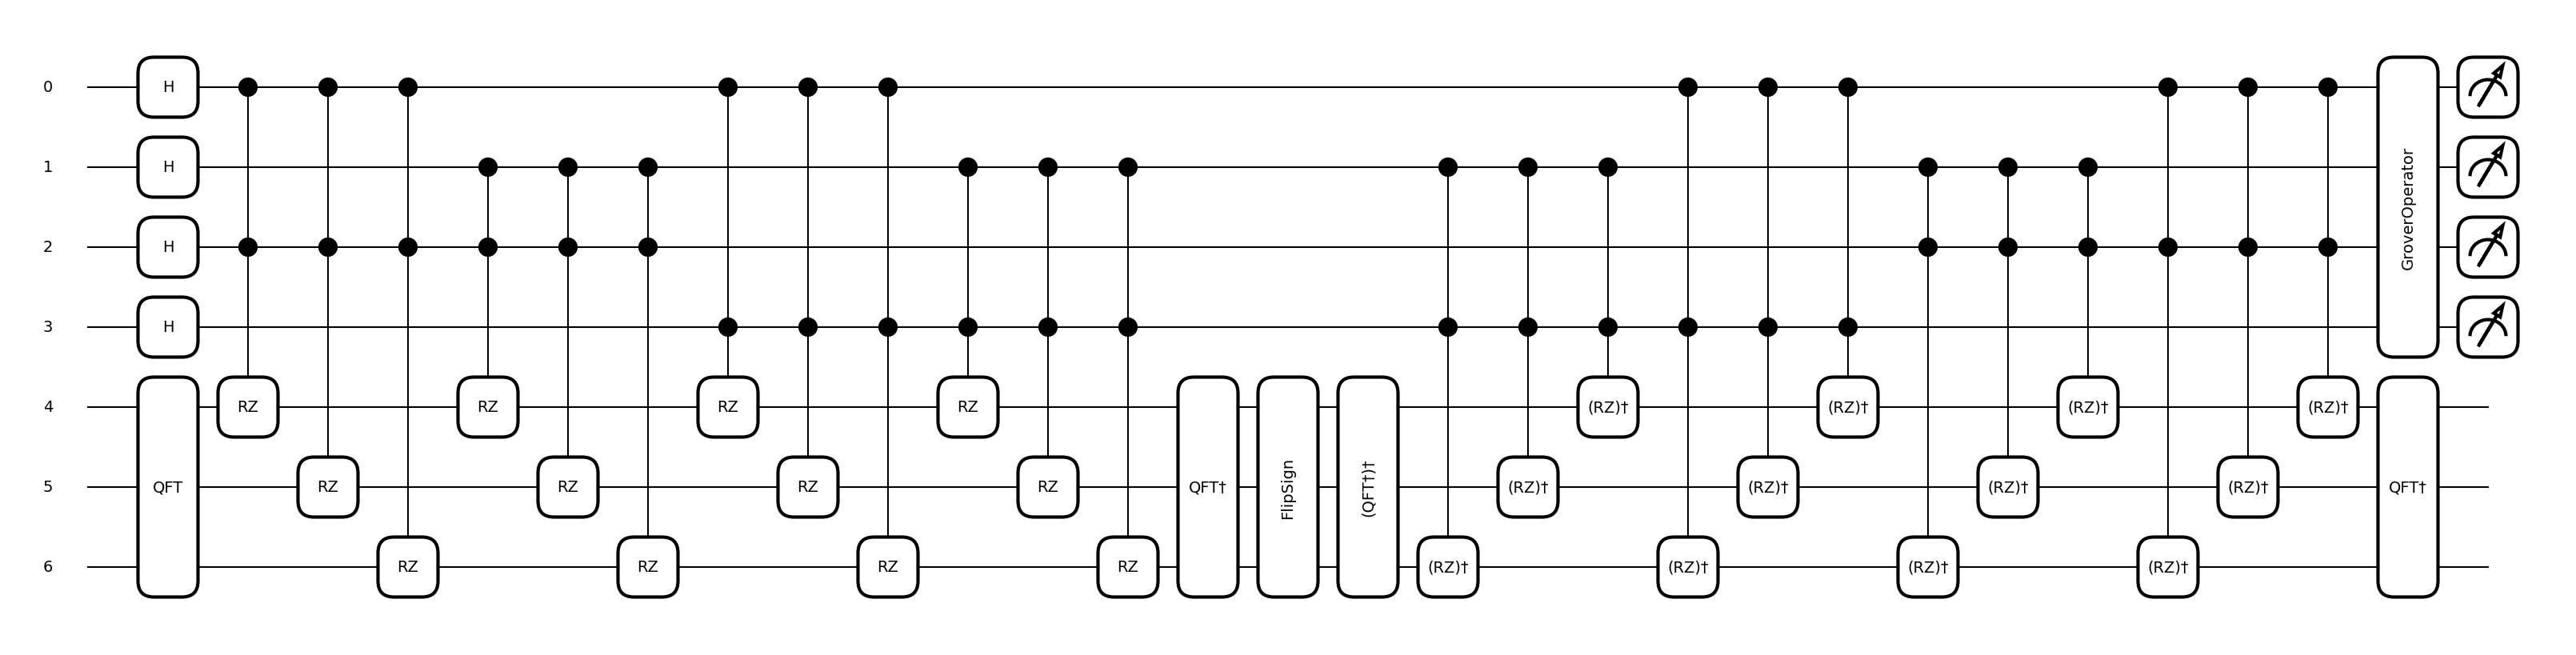

In [3]:
# draw circuit:
_ = qml.draw_mpl(FactorizationCircuit, style="black_white")(params)

We execute and measure the circuit on the Dynex platform:

In [4]:
dynex_circuit = DynexCircuit(config=config)
probs = dynex_circuit.execute(FactorizationCircuit, params, wires, method="probs", num_reads=10,
                            integration_steps=100, shots=1)

INFO: [DYNEX-APOLLO-RC1] Executing PennyLane quantum circuit
INFO: [DYNEX-APOLLO-RC1] Sampler initialised
INFO: [DYNEX-APOLLO-RC1] Apollo QPU chip: apollo_rc1
INFO: [DYNEX-APOLLO-RC1] Settings: num_reads=10, shots=1, annealing_time=100
INFO: [DYNEX-APOLLO-RC1] Submitting the job to Dynex.
INFO: [DYNEX-APOLLO-RC1] SUCCESS: Job created successfully (job_id=7420)
INFO: [DYNEX-APOLLO-RC1] feed_dict: {'cos_rz_4': 1, 'cos_rz_5': -1, 'cos_rz_6': 6.123233995736766e-17, 'sin_rz_4': -2.4492935982947064e-16, 'sin_rz_5': 1.2246467991473532e-16, 'sin_rz_6': 1}
INFO: [DYNEX-APOLLO-RC1] model: {'offset': '1.0', 'q': '789cad5adb6e23370cfd95bc6d5b6c8ca146d28cfa3303d7489300deae3769d12245ffbd4eecb14889a4a841f66963cbbaf0727878a47f7ffaf2631997d3feafe3f3dbf2f2b03fdefd72f76371cbd3c71f5fbede9dbf87eb5f1f5f0deb573fff7ae776c3d7bbcb0c78fcc80df1cbe1cf97e3f2fc6dffc8cc8a7f32ae3fa1bb70cbe3f1fb6ffbe3e969fffa7099e73cf8deedbc4f2e8d21cd2ef96988fee11ee265826179fd7b7f4273a00faee7cc03de2783615d3b94db0d1fffbf9a409de5766490ad

In [5]:
threshold = 0.2 # This needs to be adjusted based on the qubits/n/iterations
p = "".join(["1" if probs[i] > threshold else "0" for i in wires_p])
q = "".join(["1" if probs[i] > threshold else "0" for i in wires_q])
p_digit = int(p, 2)
q_digit = int(q, 2)
state = p +"----"+ q
print(f">>> STATE: {state} :::: P:{p_digit} -- Q:{q_digit} <<<")

>>> STATE: 11----10 :::: P:3 -- Q:2 <<<
